# Variabilité locale des prix immobiliers parisiens

**Objectif :** Analyser l'hétérogénéité des prix de l'immobilier à Paris à partir des données DVF (Demandes de Valeurs Foncières).
On se concentre sur l'importation, le nettoyage de l'échantillon brut, et les premières statistiques descriptives par arrondissement.

## 1. Préparation de l'environnement et chargement des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

pd.set_option('display.max_columns', 50)

df = pd.read_csv("mutations_d75.csv", sep=";")

df.head(3)

,idmutation,idmutinvar,idopendata,idnatmut,codservch,refdoc,datemut,anneemut,moismut,coddep,libnatmut,vefa,valeurfonc,nbdispo,nblot,nbcomm,l_codinsee,nbsection,l_section,nbpar,l_idpar,nbparmut,l_idparmut,nbsuf,sterr,...,nbapt2pp,nbapt3pp,nbapt4pp,nbapt5pp,nbmai1pp,nbmai2pp,nbmai3pp,nbmai4pp,nbmai5pp,sbati,sbatmai,sbatapt,sbatact,sapt1pp,sapt2pp,sapt3pp,sapt4pp,sapt5pp,smai1pp,smai2pp,smai3pp,smai4pp,smai5pp,codtypbien,libtypbien
0,12720526,b5b875cc3e82afbe1559b1bbeab6157f,b5b875cc3e82afbe1559b1bbeab6157f,2,NaN,NaN,2014-10-30,2014,10,75,Vente en l'état futur d'achèvement,True,360000.0,1,1,1,['75119'],1,['AO'],1,['75119000AO0086'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif
1,12738160,120ee7765ec5c132c3ad1394fb4eb803,120ee7765ec5c132c3ad1394fb4eb803,2,NaN,NaN,2014-04-24,2014,4,75,Vente en l'état futur d'achèvement,True,334000.0,1,1,1,['75114'],1,['CY'],1,['75114000CY0059'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif
2,12739989,58195de5cc7c8af9065123a10921548e,58195de5cc7c8af9065123a10921548e,2,NaN,NaN,2014-06-06,2014,6,75,Vente en l'état futur d'achèvement,True,369420.0,1,1,1,['75114'],1,['CY'],1,['75114000CY0059'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif


## 2. Nécessité de nettoyer et restreindre l'échantillon

L'échantillon brut contient l'univers complet des transactions. Pour obtenir un prix au $m^2$ pertinent, plusieurs traitements sont indispensables :
1. **Filtres de base :** Il faut ne conserver que les "ventes" classiques d'appartements (exclusion des ventes sur plan/VEFA, terrains, locaux commerciaux).
2. **Agrégation des transactions :** Dans la base DVF, une transaction comprenant plusieurs lots génère plusieurs lignes, mais la valeur foncière globale est répétée sur chaque ligne. On doit alors regrouper les données par `idmutation` (la transaction) pour sommer les surfaces avant de calculer le prix, sous peine de biaiser les résultats.

In [ ]:
# Filtres de base
df_clean = df[
    (df['libnatmut'] == 'Vente') & 
    (df['vefa'] == False) &
    (df['libtypbien'].str.contains('APPARTEMENT', na=False)) &
    (df['valeurfonc'] > 0) & 
    (df['sbati'] >= 9)
].copy()

# Agrégation par transaction (idmutation)
df_clean = df_clean.groupby('idmutation').agg({
    'valeurfonc': 'first',
    'sbati': 'sum',
    'l_codinsee': 'first'
}).reset_index()

# Calcul du prix au m2
df_clean['prix_m2'] = df_clean['valeurfonc'] / df_clean['sbati']

# Suppression des valeurs statistiques aberrantes (erreurs de saisie)
df_clean = df_clean[
    (df_clean['prix_m2'] > 1000) & 
    (df_clean['prix_m2'] < 30000)
]

print(f"Nombre de transactions avant nettoyage : {len(df)}")
print(f"Nombre de transactions viables après nettoyage : {len(df_clean)}")

Nombre de transactions avant nettoyage : 457097
Nombre de transactions viables après nettoyage : 337417


## 3. Statistiques Descriptives Globales

Maintenant que le biais des surfaces partielles et des erreurs de saisie est écarté, nous pouvons calculer des statistiques descriptives sur l'ensemble de la ville.

In [3]:
print("--- Statistiques Globales (Paris) ---")
print("Prix moyen au m2 :", round(df_clean['prix_m2'].mean(), 2), "€")
print("Prix médian au m2 :", round(df_clean['prix_m2'].median(), 2), "€")
print("Prix minimum au m2 :", round(df_clean['prix_m2'].min(), 2), "€")
print("Prix maximum au m2 :", round(df_clean['prix_m2'].max(), 2), "€")

--- Statistiques Globales (Paris) ---
Prix moyen au m2 : 9730.55 €
Prix médian au m2 : 9500.0 €
Prix minimum au m2 : 1000.71 €
Prix maximum au m2 : 29975.0 €


## 4. Hétérogénéité spatiale : Analyse inter-arrondissements

En préparation de l'analyse spatiale demandée par le projet, nous formatons les codes géographiques (INSEE) pour extraire le numéro de l'arrondissement. Nous calculons ensuite le prix moyen par secteur géographique pour observer les premières disparités.

--- Tableau récapitulatif par Arrondissement ---


,Nb_Ventes,Surface_Moyenne_m2,Prix_moyen_m2,Prix_median_m2
arrondissement,,,,
1,3412,58.0,11943.0,11587.0
2,5130,48.0,10698.0,10725.0
3,7296,53.0,11330.0,11251.0
4,5442,57.0,12278.0,12092.0
5,8945,53.0,11553.0,11522.0
6,8430,69.0,13722.0,13422.0
7,9815,84.0,13551.0,13056.0
8,7526,94.0,11598.0,11227.0
9,12420,59.0,10256.0,10259.0


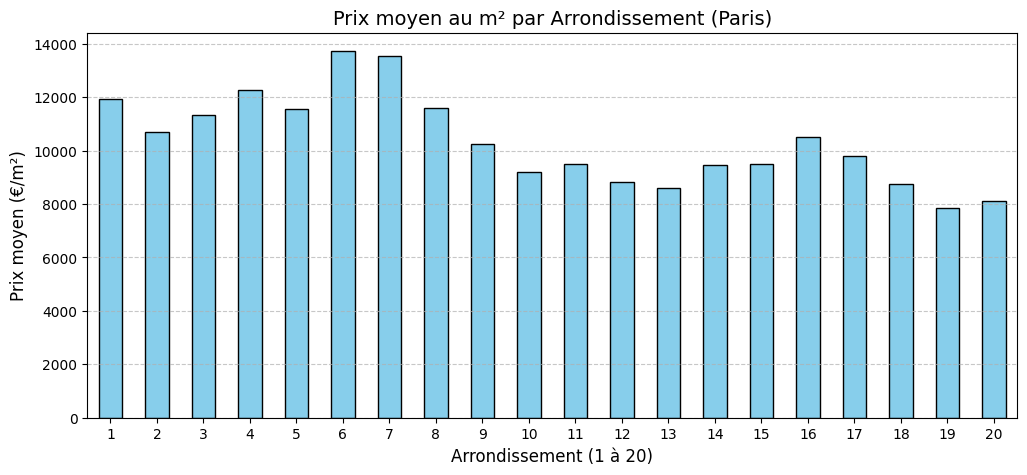

In [6]:
# Nettoyage de l'arrondissement
def extraire_numero_arrondissement(valeur):
    try:
        code = ast.literal_eval(valeur)[0]
        return int(code[-2:])
    except:
        return None

df_clean['arrondissement'] = df_clean['l_codinsee'].apply(extraire_numero_arrondissement)
df_clean = df_clean.dropna(subset=['arrondissement']) 

# Tableau descriptif par arrondissement
resume_arrondissement = df_clean.groupby('arrondissement').agg(
    Nb_Ventes=('idmutation', 'count'),          # Volume
    Surface_Moyenne_m2=('sbati', 'mean'),       # Typologie
    Prix_moyen_m2=('prix_m2', 'mean'),          # Prix
    Prix_median_m2=('prix_m2', 'median')        # Prix médian
).round(0)

print("--- Tableau récapitulatif par Arrondissement ---")
display(resume_arrondissement)
print("\n")

# Diagramme en barres des prix moyens
plt.figure(figsize=(12, 5))
resume_arrondissement['Prix_moyen_m2'].plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Prix moyen au m² par Arrondissement (Paris)', fontsize=14)
plt.ylabel('Prix moyen (€/m²)', fontsize=12)
plt.xlabel('Arrondissement (1 à 20)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

plt.show()

## 5. Dispersion intra-arrondissement

La moyenne observée précédemment lisse les variations. Nous pouvons aussi observer la dispersion des prix à l'intérieur de chaque arrondissement sous forme de boxplot pour se rapprocher de ce qui nous intéresse dans la suite du projet.

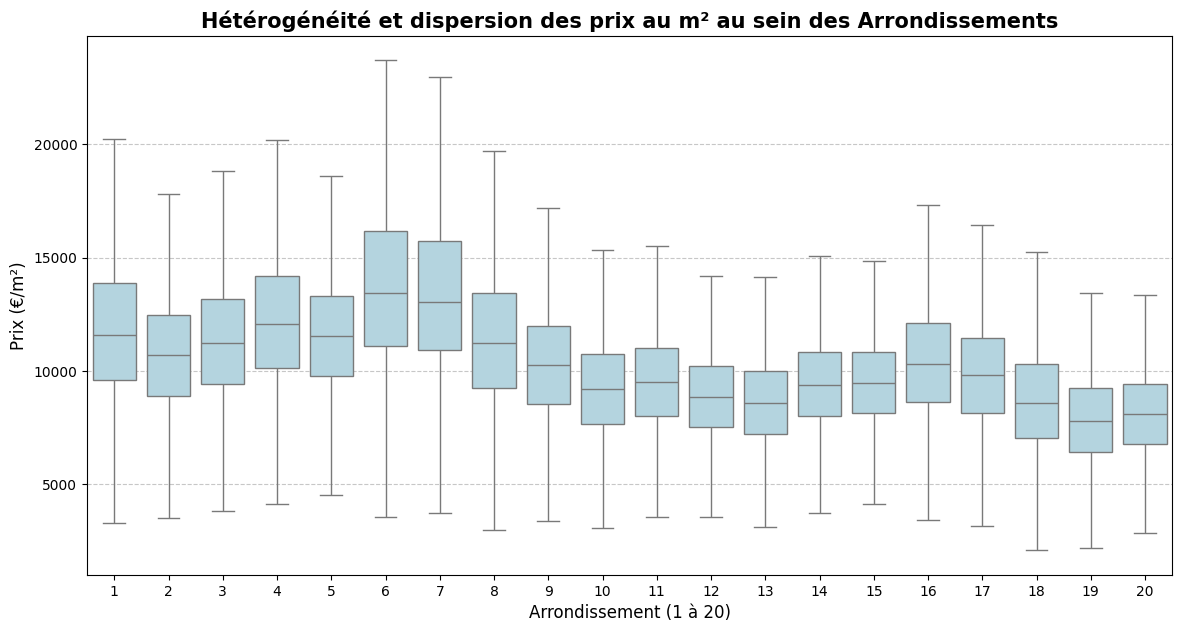

In [ ]:
# Boxplot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_clean, 
    x='arrondissement', 
    y='prix_m2', 
    color='lightblue', 
    showfliers=False # On masque les aberrations isolées pour la lisibilité
)

plt.title('Hétérogénéité et dispersion des prix au m² au sein des Arrondissements', fontsize=15, fontweight='bold')
plt.ylabel('Prix (€/m²)', fontsize=12)
plt.xlabel('Arrondissement (1 à 20)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Conclusion de la phase exploratoire

1. **La nécessité méthodologique :** L'exploitation des données DVF brutes requiert un retraitement strict (exclusion des VEFA, agrégation par transaction) pour garantir la fiabilité de la variable "prix au m²". Même les traitements appliqués ne sont pas sûrs : les bornes de prix que l'on utilise pour filtrer sont arbitraires et il se peut que nous en supprimions trop ou pas assez.
2. **Une double hétérogénéité :** Les résultats confirment une forte disparité inter-arrondissements, mais surtout une variance très élevée **au sein même** de certains arrondissements (visibles sur l'étalement des boxplots).
3. **Perspectives :** Pour comprendre l'origine de cette hétérogénéité locale (proximité des transports, espaces verts, bruit...), il sera nécessaire de passer à une approche micro-locale, en utilisant des coordonnées géographiques plus fines (carreaux de 200m, IRIS).

## Remarques méthodologiques et limites de l'exercice

Le nettoyage de la base de données a conduit à écarter environ 26 % des observations initiales (passant de ~457k lignes brutes à ~337k transactions viables). Cette "purge" a permis d'éliminer :
- Les données aberrantes ou incomplètes (ex: ventes en VEFA avec surface bâtie non encore déclarée).
- Les transactions "non-significatives" du marché de l'habitat résidentiel (caves, parkings, locaux commerciaux, terrains).
- Les ventes symboliques, intrafamiliales ou échanges (ex: des transactions affichées à 1€ ou à des prix au m² irréalistes).
- Les micro-surfaces (inférieures à 9 m²), dont la dynamique de prix au m² est spéculative et déconnectée du marché classique du logement.

**Pistes pour la suite du projet :**
L'agrégation des données sur l'ensemble de la période disponible (vraisemblablement plusieurs années) lisse les cycles de marché (hausse puis baisse récente des prix parisiens). Pour une analyse finale de l'hétérogénéité spatiale pure, il sera sans doute nécessaire de réaliser des coupes transversales par année (ex: filtrer sur `anneemut == 2023`). Un géocodage à l'échelle du quartier compléterait cette première approche par arrondissement.